# MM-EdgeDP Results

This notebook loads results from two CSVs and produces all plots and tables.

**Prerequisites:**
- `outputs/sweep_phase1.csv` — produced by `python sweep.py --phase 1`
- `outputs/sweep_phase2.csv` — produced by `python sweep.py --phase 2`
- `outputs/baseline_results.csv` — produced by `python baselines.py`

**Sections:**
1. Phase 1 — public_frac × dict_per_class heatmap
2. Phase 2 — epsilon vs. val_acc privacy-utility curve
3. Phase 3 — all methods × all datasets: accuracy + empirical privacy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
FIGSIZE = (7, 4)

PHASE1_CSV   = Path('outputs/sweep_phase1.csv')
PHASE2_CSV   = Path('outputs/sweep_phase2.csv')
BASELINE_CSV = Path('outputs/baseline_results.csv')

def load_csv(path):
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run the corresponding script first.\n"
            f"  sweep_phase1.csv   → python sweep.py --phase 1\n"
            f"  sweep_phase2.csv   → python sweep.py --phase 2\n"
            f"  baseline_results.csv → python baselines.py"
        )
    df = pd.read_csv(path)
    print(f'Loaded {path}: {len(df)} rows')
    return df

---
## Phase 1 — Hyperparameter Grid: public_frac × dict_per_class

Cora, ε = 1.0, averaged over seeds.

In [3]:
p1 = load_csv(PHASE1_CSV)
p1 = p1[p1.get('status', 'ok') == 'ok'].copy()
print(f'Phase 1 rows: {len(p1)}')
p1.head()

Loaded outputs/sweep_phase1.csv: 36 rows
Phase 1 rows: 36


,dataset,epsilon,public_frac,dict_per_class,seed,val_acc,majority_acc,dict_size,n_train,n_val,n_public,mean_entropy,mean_top_prob,unique_proto_ratio,status,error
0,Cora,1.0,0.02,4,0,0.5009,0.3024,28,2118,539,51,1.3863,0.2500,1.0,ok,NaN
1,Cora,1.0,0.02,4,1,0.5510,0.3024,28,2118,539,51,1.3853,0.2600,1.0,ok,NaN
2,Cora,1.0,0.02,4,2,0.4991,0.3024,28,2118,539,51,1.3863,0.2500,1.0,ok,NaN
3,Cora,1.0,0.02,16,0,0.5083,0.3024,112,2118,539,51,2.7726,0.0625,1.0,ok,NaN
4,Cora,1.0,0.02,16,1,0.5102,0.3024,112,2118,539,51,2.7717,0.0653,1.0,ok,NaN


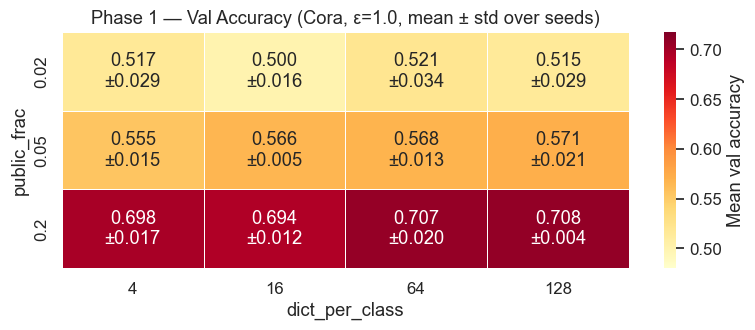

In [4]:
# Mean and std val_acc over seeds
p1_mean = (
    p1.groupby(['public_frac', 'dict_per_class'])['val_acc']
    .mean()
    .unstack('dict_per_class')
)
p1_std = (
    p1.groupby(['public_frac', 'dict_per_class'])['val_acc']
    .std()
    .unstack('dict_per_class')
)

# Format as 'mean ± std' for annotation
annot = p1_mean.copy().astype(str)
for r in p1_mean.index:
    for c in p1_mean.columns:
        m = p1_mean.loc[r, c]
        s = p1_std.loc[r, c]
        annot.loc[r, c] = f'{m:.3f}\n±{s:.3f}' if not np.isnan(s) else f'{m:.3f}'

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(
    p1_mean,
    annot=annot, fmt='',
    cmap='YlOrRd', vmin=p1_mean.values.min() - 0.02, vmax=p1_mean.values.max() + 0.01,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean val accuracy'},
)
ax.set_xlabel('dict_per_class')
ax.set_ylabel('public_frac')
ax.set_title('Phase 1 — Val Accuracy (Cora, ε=1.0, mean ± std over seeds)')
plt.tight_layout()
plt.savefig('outputs/phase1_heatmap.pdf', bbox_inches='tight')
plt.show()

In [5]:
# Readable table: rows = public_frac, cols = dict_per_class
display_df = p1_mean.copy()
display_df.index = [f'{v:.0%}' for v in display_df.index]
display_df.index.name = 'public_frac'
display_df.columns = [f'K={c}' for c in display_df.columns]
display_df.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=None)

,K=4,K=16,K=64,K=128
public_frac,,,,
2%,0.5170,0.5003,0.5207,0.5151
5%,0.5553,0.5659,0.5677,0.5714
20%,0.6976,0.6939,0.7069,0.7075


---
## Phase 2 — Privacy-Utility Curve: Epsilon

Cora, public_frac = 20%, best dict_per_class from Phase 1.

In [6]:
p2 = load_csv(PHASE2_CSV)
p2 = p2[p2.get('status', 'ok') == 'ok'].copy()
print(f'Phase 2 rows: {len(p2)}')

p2_stats = (
    p2.groupby('epsilon')['val_acc']
    .agg(['mean', 'std'])
    .reset_index()
)
p2_stats

Loaded outputs/sweep_phase2.csv: 18 rows
Phase 2 rows: 18


,epsilon,mean,std
0,0.1,0.707467,0.002136
1,0.5,0.708100,0.003843
2,1.0,0.701300,0.005600
3,2.0,0.706233,0.004272
4,5.0,0.706267,0.003859
5,10.0,0.704400,0.009143


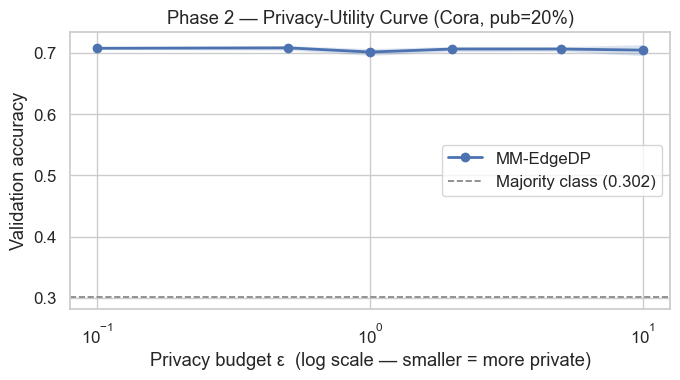

In [7]:
# Majority class baseline (constant across epsilon)
majority_acc = p2['majority_acc'].mean() if 'majority_acc' in p2.columns else None

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(p2_stats.epsilon, p2_stats['mean'], marker='o', linewidth=2, label='MM-EdgeDP')
ax.fill_between(
    p2_stats.epsilon,
    p2_stats['mean'] - p2_stats['std'],
    p2_stats['mean'] + p2_stats['std'],
    alpha=0.2,
)
if majority_acc is not None:
    ax.axhline(majority_acc, color='gray', linestyle='--', linewidth=1.2,
               label=f'Majority class ({majority_acc:.3f})')
ax.set_xscale('log')
ax.set_xlabel('Privacy budget ε  (log scale — smaller = more private)')
ax.set_ylabel('Validation accuracy')
ax.set_title('Phase 2 — Privacy-Utility Curve (Cora, pub=20%)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/phase2_epsilon_curve.pdf', bbox_inches='tight')
plt.show()

---
## Phase 3 — Dataset Comparison with Empirical Privacy

5 methods × 3 datasets. Val accuracy + white-box and black-box attack AUC-ROC.

- **AUC ≈ 0.5** = no edge leakage (attacker at chance)
- **AUC ≈ 1.0** = near-perfect edge inference

Ideal method: **top-left** of the accuracy–privacy scatter (high accuracy, low AUC).

In [8]:
bl = load_csv(BASELINE_CSV)
bl_ok = bl[bl.get('status', 'ok') == 'ok'].copy()
print(bl_ok[['dataset','method','val_acc','wb_auc','bb_auc']].head(10))

Loaded outputs/baseline_results.csv: 30 rows
  dataset        method  val_acc  wb_auc  bb_auc
0    Cora  Gaussian SGC   0.2208  0.5000  0.5000
1    Cora       Edge RR   0.3024  0.5072  0.6033
2    Cora       GAP-EDP   0.7551  0.8869  0.8609
3    Cora    Public GCN   0.7161  0.7631  0.7787
4    Cora     MM-EdgeDP   0.7050  0.7412  0.7380
5    Cora  Gaussian SGC   0.2542  0.5000  0.5000
6    Cora       Edge RR   0.3024  0.5002  0.6562
7    Cora       GAP-EDP   0.7217  0.8790  0.8474
8    Cora    Public GCN   0.7087  0.7829  0.7391
9    Cora     MM-EdgeDP   0.7069  0.7266  0.7167


In [9]:
# Aggregate over seeds
agg = (
    bl_ok.groupby(['dataset', 'method'])[['val_acc', 'wb_auc', 'bb_auc']]
    .agg(['mean', 'std'])
)
agg.columns = ['_'.join(c) for c in agg.columns]
agg = agg.reset_index()
agg

,dataset,method,val_acc_mean,val_acc_std,wb_auc_mean,wb_auc_std,bb_auc_mean,bb_auc_std
0,AmazonPhoto,Edge RR,0.254100,0.000000,0.595200,0.015583,0.607833,0.035818
1,AmazonPhoto,GAP-EDP,0.907633,0.003406,0.884400,0.018007,0.881267,0.024837
2,AmazonPhoto,Gaussian SGC,0.247967,0.013806,0.500000,0.000000,0.500000,0.000000
3,AmazonPhoto,MM-EdgeDP,0.890433,0.007355,0.785967,0.019297,0.799333,0.024306
4,AmazonPhoto,Public GCN,0.896533,0.004934,0.852800,0.001277,0.820400,0.015704
5,Cora,Edge RR,0.302400,0.000000,0.500400,0.006702,0.641933,0.033836
6,Cora,GAP-EDP,0.729733,0.022455,0.881533,0.004650,0.859833,0.011936
7,Cora,Gaussian SGC,0.235633,0.017010,0.500000,0.000000,0.500000,0.000000
8,Cora,MM-EdgeDP,0.704400,0.002848,0.730900,0.008960,0.730000,0.011597
9,Cora,Public GCN,0.700667,0.020657,0.780600,0.016471,0.762100,0.020561


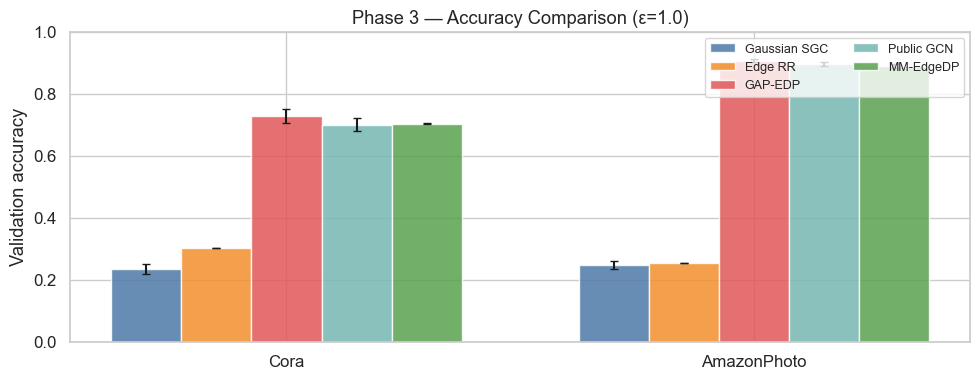

In [11]:
# --- Grouped bar chart: accuracy by dataset and method ---
METHOD_ORDER = ['Gaussian SGC', 'Edge RR', 'GAP-EDP', 'Public GCN', 'MM-EdgeDP']
DATASET_ORDER = ['Cora', 'AmazonPhoto']
METHOD_COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

pivot_acc = (
    bl_ok.groupby(['dataset','method'])['val_acc'].mean()
    .unstack('method')
    .reindex(index=DATASET_ORDER, columns=METHOD_ORDER)
)
pivot_std = (
    bl_ok.groupby(['dataset','method'])['val_acc'].std()
    .unstack('method')
    .reindex(index=DATASET_ORDER, columns=METHOD_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(DATASET_ORDER))
n_methods = len(METHOD_ORDER)
width = 0.15
offsets = (np.arange(n_methods) - n_methods / 2 + 0.5) * width

for i, (method, color) in enumerate(zip(METHOD_ORDER, METHOD_COLORS)):
    means = pivot_acc[method].values
    stds  = pivot_std[method].fillna(0).values
    ax.bar(x + offsets[i], means, width, yerr=stds, capsize=3,
           label=method, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(DATASET_ORDER)
ax.set_ylabel('Validation accuracy')
ax.set_title('Phase 3 — Accuracy Comparison (ε=1.0)')
ax.legend(loc='upper right', ncol=2, fontsize=9)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('outputs/phase3_accuracy_bars.pdf', bbox_inches='tight')
plt.show()

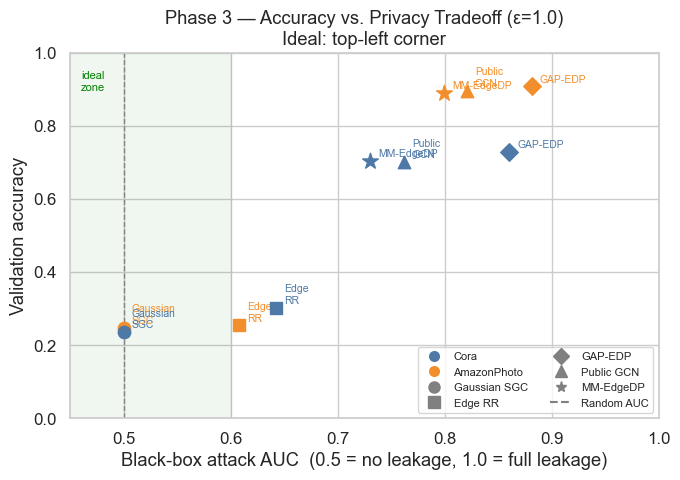

In [13]:
# --- Privacy-utility scatter: BB AUC (x) vs val_acc (y) ---
DATASET_COLORS  = {'Cora': '#4e79a7', 'AmazonPhoto': '#f28e2b'}
METHOD_MARKERS  = {
    'Gaussian SGC': 'o', 'Edge RR': 's', 'GAP-EDP': 'D',
    'Public GCN': '^', 'MM-EdgeDP': '*',
}
METHOD_SIZE = {'Gaussian SGC': 80, 'Edge RR': 80, 'GAP-EDP': 80, 'Public GCN': 80, 'MM-EdgeDP': 140}

fig, ax = plt.subplots(figsize=(7, 5))

for _, row in agg.iterrows():
    ds, method = row['dataset'], row['method']
    if ds not in DATASET_COLORS or method not in METHOD_MARKERS:
        continue
    ax.scatter(
        row['bb_auc_mean'], row['val_acc_mean'],
        color=DATASET_COLORS[ds],
        marker=METHOD_MARKERS[method],
        s=METHOD_SIZE[method],
        zorder=3,
        label=f'{method} / {ds}',
    )
    ax.annotate(
        method.replace(' ', '\n'),
        (row['bb_auc_mean'], row['val_acc_mean']),
        textcoords='offset points', xytext=(6, 3), fontsize=7.5, color=DATASET_COLORS[ds],
    )

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.0, label='Random AUC (0.5)')
ax.set_xlabel('Black-box attack AUC  (0.5 = no leakage, 1.0 = full leakage)')
ax.set_ylabel('Validation accuracy')
ax.set_title('Phase 3 — Accuracy vs. Privacy Tradeoff (ε=1.0)\nIdeal: top-left corner')
ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.0, 1.0)

# Annotation: shade the ideal region
ax.axvspan(0.45, 0.60, alpha=0.06, color='green', label='Low-leakage zone')
ax.text(0.46, 0.95, 'ideal\nzone', fontsize=8, color='green', va='top')

# Dataset legend patches
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=9, label=ds)
    for ds, c in DATASET_COLORS.items()
] + [
    Line2D([0],[0], marker=m, color='gray', markersize=8, label=method, linestyle='none')
    for method, m in METHOD_MARKERS.items()
] + [Line2D([0],[0], color='gray', linestyle='--', label='Random AUC')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('outputs/phase3_privacy_scatter.pdf', bbox_inches='tight')
plt.show()

In [14]:
# --- Summary table ---
summary = agg[['dataset','method','val_acc_mean','val_acc_std','wb_auc_mean','bb_auc_mean']].copy()
summary.columns = ['Dataset','Method','Val Acc','±','WB AUC','BB AUC']
summary = summary.sort_values(['Dataset','Val Acc'], ascending=[True, False])

# Add DP type column
dp_map = {
    'Gaussian SGC': '(ε,δ)-DP',
    'Edge RR':      'ε-DP',
    'GAP-EDP':      '(ε,δ)-DP',
    'Public GCN':   'none',
    'MM-EdgeDP':    'ε-DP',
}
summary.insert(2, 'DP Type', summary['Method'].map(dp_map))

summary.style\
    .format({'Val Acc': '{:.4f}', '±': '{:.4f}', 'WB AUC': '{:.4f}', 'BB AUC': '{:.4f}'})\
    .hide(axis='index')\
    .set_caption('Phase 3 — Full Comparison (ε=1.0, mean over seeds)')

Dataset,Method,DP Type,Val Acc,±,WB AUC,BB AUC
AmazonPhoto,GAP-EDP,"(ε,δ)-DP",0.9076,0.0034,0.8844,0.8813
AmazonPhoto,Public GCN,none,0.8965,0.0049,0.8528,0.8204
AmazonPhoto,MM-EdgeDP,ε-DP,0.8904,0.0074,0.7860,0.7993
AmazonPhoto,Edge RR,ε-DP,0.2541,0.0000,0.5952,0.6078
AmazonPhoto,Gaussian SGC,"(ε,δ)-DP",0.2480,0.0138,0.5000,0.5000
Cora,GAP-EDP,"(ε,δ)-DP",0.7297,0.0225,0.8815,0.8598
Cora,MM-EdgeDP,ε-DP,0.7044,0.0028,0.7309,0.7300
Cora,Public GCN,none,0.7007,0.0207,0.7806,0.7621
Cora,Edge RR,ε-DP,0.3024,0.0000,0.5004,0.6419
Cora,Gaussian SGC,"(ε,δ)-DP",0.2356,0.0170,0.5000,0.5000


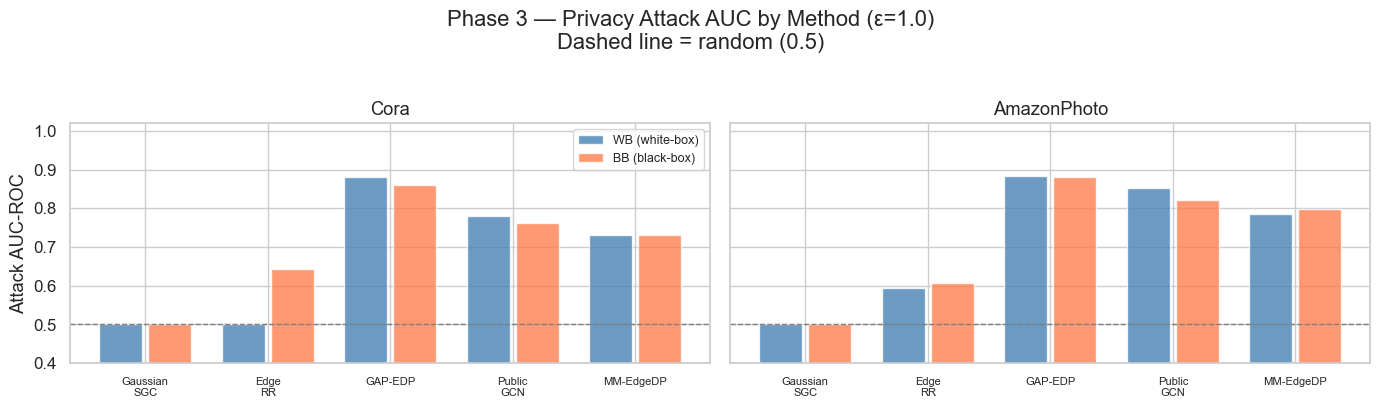

In [16]:
# --- White-box vs Black-box AUC comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, ds in zip(axes, DATASET_ORDER):
    sub = agg[agg.dataset == ds].set_index('method').reindex(METHOD_ORDER)
    x_pos = np.arange(len(METHOD_ORDER))
    ax.bar(x_pos - 0.2, sub['wb_auc_mean'], 0.35, label='WB (white-box)',
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + 0.2, sub['bb_auc_mean'], 0.35, label='BB (black-box)',
           color='coral', alpha=0.8)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.0)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [m.replace(' ', '\n') for m in METHOD_ORDER], fontsize=8)
    ax.set_title(ds)
    ax.set_ylim(0.4, 1.02)
    if ax == axes[0]:
        ax.set_ylabel('Attack AUC-ROC')
        ax.legend(fontsize=9)

fig.suptitle('Phase 3 — Privacy Attack AUC by Method (ε=1.0)\n'
             'Dashed line = random (0.5)', y=1.02)
plt.tight_layout()
plt.savefig('outputs/phase3_attack_aucs.pdf', bbox_inches='tight')
plt.show()